<a href="https://colab.research.google.com/github/Raffy0-1/DHC-Phase-2-ML-Task_5/blob/main/auto_tagging_support_tickets_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auto Tagging Support Tickets Using LLM

This notebook walks through the full pipeline for automatically tagging support tickets into categories using large language models.

We cover five phases in order:

- **Phase 1** — Loading and exploring the dataset
- **Phase 2** — Zero-shot classification (no examples in prompt)
- **Phase 3** — Few-shot classification (examples baked into prompt)
- **Phase 4** — Fine-tuning BERT on our labeled data (needs GPU)
- **Phase 5** — Evaluating and comparing all three approaches

Everything GPU-heavy is saved to Google Drive so a Colab session restart never costs you retraining time.

---
## Phase 1 — Dataset Loading and Exploration

Before touching any model, we need to understand our data.

**What is the dataset?**  
We are using `bitext/Bitext-customer-support-llm-chatbot-training-dataset` from Hugging Face. It contains 27,000 real customer support utterances — things like *'I need to cancel my order'*, *'my payment failed'*, *'I cannot log into my account'*. Each row has three columns that matter: `instruction` (the customer message), `category` (high-level group like ACCOUNT or ORDER), and `intent` (specific action like `cancel_order` or `payment_issue`).

**Why this dataset?**  
These are actual support ticket texts with actual support labels. No emotion remapping or keyword hacks needed — the intents already mean exactly what we want.

**Why explore first?**  
If you skip this step you end up building a model on data you do not understand. Class imbalance, text length distribution, and the number of unique intents all affect every downstream decision.

In [ ]:
# installing all required libraries upfront so nothing breaks mid-notebook
# datasets     -> Hugging Face library for loading datasets with one line
# transformers -> Hugging Face library for models, tokenizers, pipelines
# torch        -> PyTorch, the deep learning framework BERT runs on
# scikit-learn -> for computing F1, precision, recall later
# matplotlib   -> for plotting charts
# accelerate   -> makes Hugging Face Trainer faster on GPU

!pip install -q datasets transformers torch scikit-learn matplotlib accelerate

In [ ]:
# mounting Google Drive so we can save and load files across sessions
# when Colab disconnects, everything in /content disappears
# but /content/drive/MyDrive persists as long as your Drive account exists

from google.colab import drive
drive.mount('/content/drive')

import os

# creating a project folder inside Drive to keep everything organized
DRIVE_PATH = '/content/drive/MyDrive/auto_tagging_project'
os.makedirs(DRIVE_PATH, exist_ok=True)

print(f'Drive mounted. Project folder ready at: {DRIVE_PATH}')

Mounted at /content/drive
Drive mounted. Project folder ready at: /content/drive/MyDrive/auto_tagging_project


In [ ]:
# importing everything we will use throughout this notebook
# grouping all imports here so you can see the full dependency list at a glance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import torch

from datasets import load_dataset
from transformers import pipeline

# checking if a GPU is available right now
# cuda is NVIDIA's GPU computing platform that PyTorch uses
# device=0 means first GPU, device=-1 means use CPU
device = 0 if torch.cuda.is_available() else -1
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name:', torch.cuda.get_device_name(0))

GPU available: True
GPU name: Tesla T4


In [ ]:
# loading the bitext customer support dataset from Hugging Face hub
# this is a real customer support dataset with 27k utterances and intent labels
# no deprecated scripts, loads cleanly via the datasets library

print('Loading bitext customer support dataset...')
raw_dataset = load_dataset(
    'bitext/Bitext-customer-support-llm-chatbot-training-dataset'
)
print(raw_dataset)

# converting to a pandas DataFrame — easier to explore and slice than a HF Dataset object
df = pd.DataFrame(raw_dataset['train'])

print('\nShape:', df.shape)
print('\nAll columns:', df.columns.tolist())
df.head(10)

Loading bitext customer support dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})

Shape: (26872, 5)

All columns: ['flags', 'instruction', 'category', 'intent', 'response']


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...
5,BI,can you help me cancel order {{Order Number}}?,ORDER,cancel_order,"Of course, I'm here to assist you in canceling..."
6,BCLN,"I can no longer afford order {{Order Number}},...",ORDER,cancel_order,I pick up what you're putting down that you're...
7,BL,I am trying to cancel purchase {{Order Number}},ORDER,cancel_order,I've understood that you're seeking assistance...
8,BL,I have got to cancel purchase {{Order Number}},ORDER,cancel_order,I'm sensitive to the fact that you're seeking ...
9,BLQ,i need help canceling purchase {{Order Number}},ORDER,cancel_order,I perceive that you're seeking assistance with...


In [ ]:
# understanding what columns we actually care about
# instruction -> the raw customer message (this is our ticket text)
# category    -> high-level group e.g. ACCOUNT, ORDER, PAYMENT
# intent      -> specific action e.g. cancel_order, payment_issue, track_order

print('=== Sample instruction (ticket text) ===')
print(df['instruction'].iloc[0])

print('\n=== Unique high-level categories ===')
print(sorted(df['category'].unique()))

print('\n=== Unique intents ===')
print(sorted(df['intent'].unique()))

print('\n=== Intent distribution ===')
print(df['intent'].value_counts())

=== Sample instruction (ticket text) ===
question about cancelling order {{Order Number}}

=== Unique high-level categories ===
['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']

=== Unique intents ===
['cancel_order', 'change_order', 'change_shipping_address', 'check_cancellation_fee', 'check_invoice', 'check_payment_methods', 'check_refund_policy', 'complaint', 'contact_customer_service', 'contact_human_agent', 'create_account', 'delete_account', 'delivery_options', 'delivery_period', 'edit_account', 'get_invoice', 'get_refund', 'newsletter_subscription', 'payment_issue', 'place_order', 'recover_password', 'registration_problems', 'review', 'set_up_shipping_address', 'switch_account', 'track_order', 'track_refund']

=== Intent distribution ===
intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1

In [ ]:
# mapping the bitext intents to our 7 support ticket tag categories
# the bitext dataset has ~20 specific intents — grouping them into broader
# actionable categories that a real support system would use
# this is a deliberate design choice you can explain in your portfolio

INTENT_TO_TAG = {
    # billing and payment intents
    'check_invoice':            'billing',
    'get_invoice':              'billing',
    'check_refund_policy':      'billing',
    'get_refund':               'billing',
    'track_refund':             'billing',
    'payment_issue':            'billing',

    # order and delivery intents
    'place_order':              'delivery',
    'cancel_order':             'delivery',
    'change_order':             'delivery',
    'track_order':              'delivery',
    'delivery_options':         'delivery',
    'delivery_period':          'delivery',
    'change_shipping_address':  'delivery',

    # account and login intents
    'create_account':           'account_access',
    'delete_account':           'account_access',
    'edit_account':             'account_access',
    'switch_account':           'account_access',
    'recover_password':         'account_access',
    'registration_problems':    'account_access',

    # customer service and complaint intents
    'contact_customer_service': 'customer_service',
    'contact_human_agent':      'customer_service',
    'complaint':                'customer_service',

    # technical and other intents
    'check_cancellation_fee':   'technical_issue',
    'newsletter_subscription':  'technical_issue',

    # positive intents
    'review':                   'positive_feedback',
    'feedback':                 'positive_feedback',
}

# applying the mapping — any intent not in the dict gets general_complaint as fallback
df['primary_tag'] = df['intent'].map(INTENT_TO_TAG).fillna('general_complaint')

# wrapping the tag in a list because our pipeline always works with tag lists
# in a real system one ticket can have multiple tags, so we always store as list
df['true_tags'] = df['primary_tag'].apply(lambda x: [x])

print('Tag distribution after mapping:')
print(df['primary_tag'].value_counts())
print('\nSample rows:')
df[['instruction', 'intent', 'primary_tag']].head(10)

Tag distribution after mapping:
primary_tag
delivery             6955
billing              5990
account_access       5986
customer_service     2999
general_complaint    1996
technical_issue      1949
positive_feedback     997
Name: count, dtype: int64

Sample rows:


,instruction,intent,primary_tag
0,question about cancelling order {{Order Number}},cancel_order,delivery
1,i have a question about cancelling oorder {{Or...,cancel_order,delivery
2,i need help cancelling puchase {{Order Number}},cancel_order,delivery
3,I need to cancel purchase {{Order Number}},cancel_order,delivery
4,"I cannot afford this order, cancel purchase {{...",cancel_order,delivery
5,can you help me cancel order {{Order Number}}?,cancel_order,delivery
6,"I can no longer afford order {{Order Number}},...",cancel_order,delivery
7,I am trying to cancel purchase {{Order Number}},cancel_order,delivery
8,I have got to cancel purchase {{Order Number}},cancel_order,delivery
9,i need help canceling purchase {{Order Number}},cancel_order,delivery


Text length stats (in words):
count    26872.000000
mean         8.690979
std          2.605004
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         16.000000
Name: text_length, dtype: float64


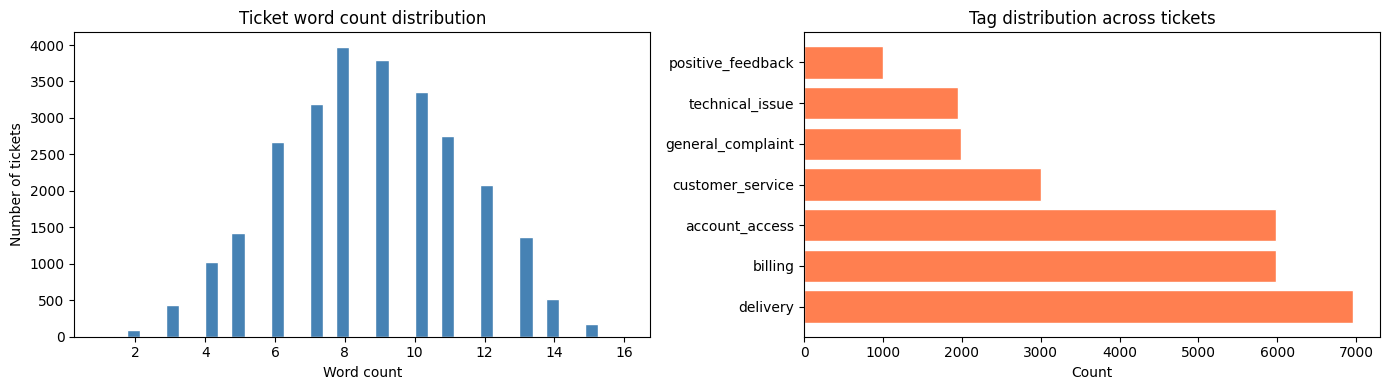

Exploration chart saved to Drive.


In [ ]:
# exploring ticket text lengths to understand what we are working with
# very short tickets give less signal to the model
# very long tickets get truncated by BERT at 512 tokens

df['text_length'] = df['instruction'].str.split().str.len()

print('Text length stats (in words):')
print(df['text_length'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# plotting word count distribution across all tickets
axes[0].hist(df['text_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Ticket word count distribution')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of tickets')

# plotting how many tickets fall into each tag category
tag_counts = df['primary_tag'].value_counts()
axes[1].barh(tag_counts.index, tag_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Tag distribution across tickets')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/data_exploration.png', dpi=120, bbox_inches='tight')
plt.show()
print('Exploration chart saved to Drive.')

In [ ]:
# saving the cleaned DataFrame to Drive before moving on
# true_tags is a list so serializing it as a JSON string in the CSV
# we deserialize it back whenever we load from Drive

df_save = df[['instruction', 'intent', 'category', 'primary_tag', 'true_tags']].copy()
df_save['true_tags'] = df_save['true_tags'].apply(json.dumps)

CLEANED_CSV = f'{DRIVE_PATH}/cleaned_tickets.csv'
df_save.to_csv(CLEANED_CSV, index=False)
print(f'Cleaned data saved to: {CLEANED_CSV}')
print(f'Total tickets: {len(df)}')

Cleaned data saved to: /content/drive/MyDrive/auto_tagging_project/cleaned_tickets.csv
Total tickets: 26872


---
## Phase 2 — Zero-Shot Classification

**What is zero-shot classification?**  
We give the model a piece of text and a list of possible labels and ask it to decide which label fits best, without ever having seen a training example. The model uses its general language understanding to make this judgment.

**How does it work technically?**  
We are using `facebook/bart-large-mnli`. This model was trained on Natural Language Inference (NLI) — a task where you check whether a hypothesis follows from a premise. Zero-shot classification turns each candidate label into a hypothesis: the premise is your ticket text, and each label becomes *'This text is about billing'*. Whichever hypothesis the model says most likely entails the premise wins.

**What we will get:**  
For each ticket, a ranked list of scores for all candidate labels. We keep the top 3.

In [ ]:
# loading the zero-shot classification pipeline from Hugging Face
# pipeline() bundles model + tokenizer + inference logic into one clean object
# device=device means using GPU if available, CPU otherwise

print('Loading zero-shot classification model (bart-large-mnli)...')
zero_shot_classifier = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=device
)
print('Model loaded.')

# defining candidate labels as natural language phrases, not underscored variable names
# the model understands 'billing and payment' much better than 'billing'
CANDIDATE_LABELS = [
    'billing and payment',
    'order and delivery',
    'account access and login',
    'technical issue',
    'customer service and complaint',
    'general complaint',
    'positive feedback'
]

# mapping natural language labels back to our internal tag names
LABEL_TO_TAG = {
    'billing and payment':            'billing',
    'order and delivery':             'delivery',
    'account access and login':       'account_access',
    'technical issue':                'technical_issue',
    'customer service and complaint': 'customer_service',
    'general complaint':              'general_complaint',
    'positive feedback':              'positive_feedback'
}

Loading zero-shot classification model (bart-large-mnli)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded.


In [ ]:
# testing on one ticket first so we understand the output format before the full loop

sample_ticket = df['instruction'].iloc[0]
print('Ticket:', sample_ticket)

result = zero_shot_classifier(
    sample_ticket,
    candidate_labels=CANDIDATE_LABELS,
    multi_label=True   # multi_label=True scores each label independently
                       # multi_label=False would force all scores to sum to 1
)

print('\nFull result object:')
print(result)

# mapping the top 3 label strings back to our clean tag names
top3 = [(LABEL_TO_TAG[label], score)
        for label, score in zip(result['labels'][:3], result['scores'][:3])]
print('\nTop 3 predicted tags:')
for tag, score in top3:
    print(f'  {tag}: {score:.3f}')

Ticket: question about cancelling order {{Order Number}}

Full result object:
{'sequence': 'question about cancelling order {{Order Number}}', 'labels': ['customer service and complaint', 'technical issue', 'order and delivery', 'billing and payment', 'general complaint', 'positive feedback', 'account access and login'], 'scores': [0.8075262308120728, 0.3525558412075043, 0.15931293368339539, 0.04419754073023796, 0.022156549617648125, 0.0009060516022145748, 0.0007367544458247721]}

Top 3 predicted tags:
  customer_service: 0.808
  technical_issue: 0.353
  delivery: 0.159


In [ ]:
# running zero-shot on a stratified sample of tickets
# sampling evenly across categories so evaluation is not biased toward any one class
# set SAMPLE_SIZE = len(df) for a full run when you have time

SAMPLE_SIZE = 200

# groupby + sample giving us proportional coverage of each category
df_sample = (
    df.groupby('primary_tag', group_keys=False)
      .apply(lambda g: g.sample(min(len(g), SAMPLE_SIZE // df['primary_tag'].nunique()), random_state=42))
      .reset_index(drop=True)
)
print(f'Sample size: {len(df_sample)} tickets')
print('Per-class distribution:', df_sample['primary_tag'].value_counts().to_dict())

zero_shot_predictions = []
zero_shot_scores      = []

print(f'\nRunning zero-shot on {len(df_sample)} tickets...')

for i, text in enumerate(df_sample['instruction']):
    result = zero_shot_classifier(
        text,
        candidate_labels=CANDIDATE_LABELS,
        multi_label=True
    )
    # mapping model output labels back to our internal tag names
    top3_tags   = [LABEL_TO_TAG[l] for l in result['labels'][:3]]
    top3_scores = result['scores'][:3]

    zero_shot_predictions.append(top3_tags)
    zero_shot_scores.append(top3_scores)

    if (i + 1) % 20 == 0:
        print(f'  processed {i + 1}/{len(df_sample)} tickets')

df_sample['zero_shot_top3']   = zero_shot_predictions
df_sample['zero_shot_scores'] = zero_shot_scores

print('Done.')
df_sample[['instruction', 'true_tags', 'zero_shot_top3']].head(10)

Sample size: 196 tickets
Per-class distribution: {'account_access': 28, 'billing': 28, 'customer_service': 28, 'delivery': 28, 'general_complaint': 28, 'positive_feedback': 28, 'technical_issue': 28}

Running zero-shot on 196 tickets...


/tmp/ipykernel_2115/3842267774.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), SAMPLE_SIZE // df['primary_tag'].nunique()), random_state=42))
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  processed 20/196 tickets
  processed 40/196 tickets
  processed 60/196 tickets
  processed 80/196 tickets
  processed 100/196 tickets
  processed 120/196 tickets
  processed 140/196 tickets
  processed 160/196 tickets
  processed 180/196 tickets
Done.


,instruction,true_tags,zero_shot_top3
0,where to notify of problems with sign-up?,[account_access],"[customer_service, technical_issue, account_ac..."
1,wanna use the {{Account Type}} profile help me,[account_access],"[account_access, customer_service, technical_i..."
2,I cannot retrieve the bloody PIN code of my pr...,[account_access],"[technical_issue, account_access, customer_ser..."
3,give me information about the deletion of my {...,[account_access],"[customer_service, general_complaint, technica..."
4,i need assistance changing to the {{Account Ty...,[account_access],"[technical_issue, account_access, customer_ser..."
5,watn assistance removing a standard account,[account_access],"[technical_issue, account_access, billing]"
6,I have to report signup issues,[account_access],"[customer_service, account_access, technical_i..."
7,i dont know what to do to notify of an issue w...,[account_access],"[technical_issue, account_access, customer_ser..."
8,help me use the {{Account Type}} profile,[account_access],"[technical_issue, account_access, positive_fee..."
9,"I would like to close my standard account, can...",[account_access],"[customer_service, general_complaint, billing]"


In [ ]:
# saving zero-shot results to Drive
# serializing list columns as JSON strings so the CSV stays parseable

df_zs_save = df_sample.copy()
for col in ['true_tags', 'zero_shot_top3', 'zero_shot_scores']:
    df_zs_save[col] = df_zs_save[col].apply(json.dumps)

ZS_CSV = f'{DRIVE_PATH}/zero_shot_results.csv'
df_zs_save.to_csv(ZS_CSV, index=False)
print(f'Zero-shot results saved to: {ZS_CSV}')

Zero-shot results saved to: /content/drive/MyDrive/auto_tagging_project/zero_shot_results.csv


---
## Phase 3 — Few-Shot Classification

**What is few-shot classification?**  
Instead of giving the model zero examples, we include a handful of worked examples directly inside our prompt. The model sees: *here are 6 tickets and their correct tags — now do the same for this new ticket*.

**Why does this help?**  
Large language models are in-context learners. They pick up patterns from what you put in the prompt window. By showing a few examples you are not changing the model weights at all — you are giving the model better context about the exact format and reasoning you want.

**What model are we using?**  
We use `google/flan-t5-base` — instruction-tuned to follow structured prompts. It responds much better to few-shot formatting than a standard language model because it was specifically trained to complete instructions.

In [ ]:
import torch
from transformers import pipeline

# Assuming `device` is defined in a previous cell, e.g., in 'imports'
# device = 0 if torch.cuda.is_available() else -1

print('Loading flan-t5-base for few-shot classification...')
fewshot_pipeline = pipeline(
    'text-generation', # Changed 'text2text-generation' to 'text-generation'
    model='google/flan-t5-base',
    device=device,
    max_new_tokens=30
)
print('Model loaded.')

Loading flan-t5-base for few-shot classification...


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaF

Model loaded.


In [ ]:
# defining the few-shot examples we inject into every prompt
# choosing one clear and unambiguous example per category
# the quality of these examples directly controls how well the model performs
# bad examples = confused model, good examples = consistent and correct outputs

FEW_SHOT_EXAMPLES = [
    {
        'text': 'I was charged twice for my last order and I need a refund immediately.',
        'tag':  'billing'
    },
    {
        'text': 'My package has not arrived and the tracking number shows no updates.',
        'tag':  'delivery'
    },
    {
        'text': 'I cannot log into my account even after resetting my password.',
        'tag':  'account_access'
    },
    {
        'text': 'The app keeps crashing every time I try to place an order.',
        'tag':  'technical_issue'
    },
    {
        'text': 'Your support agent was very rude and refused to help me.',
        'tag':  'customer_service'
    },
    {
        'text': 'Everything was perfect, fast delivery and great product quality.',
        'tag':  'positive_feedback'
    },
]

ALL_KNOWN_TAGS = [
    'billing', 'delivery', 'account_access',
    'technical_issue', 'customer_service',
    'general_complaint', 'positive_feedback'
]

ALL_TAGS_STR = ', '.join(ALL_KNOWN_TAGS)

def build_fewshot_prompt(ticket_text):
    # building the prompt by writing the task instruction first
    # then showing all worked examples in a consistent Ticket / Tag format
    # then presenting the new ticket with an empty Tag for the model to complete
    # consistency in format is critical — the model learns from the repeated pattern

    prompt  = f'Classify this customer support ticket into one of: {ALL_TAGS_STR}.\n'
    prompt += 'Return only the single best matching tag from the list above.\n\n'

    for ex in FEW_SHOT_EXAMPLES:
        prompt += f'Ticket: {ex["text"]}\n'
        prompt += f'Tag: {ex["tag"]}\n\n'

    prompt += f'Ticket: {ticket_text}\n'
    prompt += 'Tag:'

    return prompt

# printing a sample prompt so we can verify exactly what the model receives
print('Sample few-shot prompt:')
print('-' * 60)
print(build_fewshot_prompt(df['instruction'].iloc[0]))
print('-' * 60)

Sample few-shot prompt:
------------------------------------------------------------
Classify this customer support ticket into one of: billing, delivery, account_access, technical_issue, customer_service, general_complaint, positive_feedback.
Return only the single best matching tag from the list above.

Ticket: I was charged twice for my last order and I need a refund immediately.
Tag: billing

Ticket: My package has not arrived and the tracking number shows no updates.
Tag: delivery

Ticket: I cannot log into my account even after resetting my password.
Tag: account_access

Ticket: The app keeps crashing every time I try to place an order.
Tag: technical_issue

Ticket: Your support agent was very rude and refused to help me.
Tag: customer_service

Ticket: Everything was perfect, fast delivery and great product quality.
Tag: positive_feedback

Ticket: question about cancelling order {{Order Number}}
Tag:
------------------------------------------------------------


In [ ]:
# testing on a single ticket before running the full loop

test_text   = df['instruction'].iloc[0]
test_prompt = build_fewshot_prompt(test_text)
raw_output  = fewshot_pipeline(test_prompt)[0]['generated_text']

print('Ticket:', test_text)
print('Raw model output:', raw_output)

def parse_fewshot_output(raw_text):
    # cleaning the output — stripping whitespace, lowercasing, replacing spaces with underscores
    cleaned = raw_text.strip().lower().replace(' ', '_').rstrip('.')

    # checking for an exact match first
    if cleaned in ALL_KNOWN_TAGS:
        return [cleaned]

    # checking if any known tag appears anywhere inside the output
    # handles cases where the model says 'billing issue' instead of just 'billing'
    for tag in ALL_KNOWN_TAGS:
        if tag in cleaned:
            return [tag]

    # falling back to general_complaint if nothing matched
    return ['general_complaint']

print('Parsed tag:', parse_fewshot_output(raw_output))

Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Ticket: question about cancelling order {{Order Number}}
Raw model output: Classify this customer support ticket into one of: billing, delivery, account_access, technical_issue, customer_service, general_complaint, positive_feedback.
Return only the single best matching tag from the list above.

Ticket: I was charged twice for my last order and I need a refund immediately.
Tag: billing

Ticket: My package has not arrived and the tracking number shows no updates.
Tag: delivery

Ticket: I cannot log into my account even after resetting my password.
Tag: account_access

Ticket: The app keeps crashing every time I try to place an order.
Tag: technical_issue

Ticket: Your support agent was very rude and refused to help me.
Tag: customer_service

Ticket: Everything was perfect, fast delivery and great product quality.
Tag: positive_feedback

Ticket: question about cancelling order {{Order Number}}
Tag:
Parsed tag: ['billing']


In [ ]:
# running few-shot on the same sample we used in Phase 2
# using the same sample is important so the Phase 5 comparison is fair

fewshot_predictions = []

print(f'Running few-shot on {len(df_sample)} tickets...')

for i, text in enumerate(df_sample['instruction']):
    prompt     = build_fewshot_prompt(text)
    raw_output = fewshot_pipeline(prompt)[0]['generated_text']
    parsed_tag = parse_fewshot_output(raw_output)
    fewshot_predictions.append(parsed_tag)

    if (i + 1) % 20 == 0:
        print(f'  processed {i + 1}/{len(df_sample)} tickets')

df_sample['few_shot_top3'] = fewshot_predictions

print('Done.')
df_sample[['instruction', 'true_tags', 'zero_shot_top3', 'few_shot_top3']].head(10)

Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running few-shot on 196 tickets...


Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  processed 20/196 tickets


Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

...

Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  processed 180/196 tickets


Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Done.


,instruction,true_tags,zero_shot_top3,few_shot_top3
0,where to notify of problems with sign-up?,[account_access],"[customer_service, technical_issue, account_ac...",[billing]
1,wanna use the {{Account Type}} profile help me,[account_access],"[account_access, customer_service, technical_i...",[billing]
2,I cannot retrieve the bloody PIN code of my pr...,[account_access],"[technical_issue, account_access, customer_ser...",[billing]
3,give me information about the deletion of my {...,[account_access],"[customer_service, general_complaint, technica...",[billing]
4,i need assistance changing to the {{Account Ty...,[account_access],"[technical_issue, account_access, customer_ser...",[billing]
5,watn assistance removing a standard account,[account_access],"[technical_issue, account_access, billing]",[billing]
6,I have to report signup issues,[account_access],"[customer_service, account_access, technical_i...",[billing]
7,i dont know what to do to notify of an issue w...,[account_access],"[technical_issue, account_access, customer_ser...",[billing]
8,help me use the {{Account Type}} profile,[account_access],"[technical_issue, account_access, positive_fee...",[billing]
9,"I would like to close my standard account, can...",[account_access],"[customer_service, general_complaint, billing]",[billing]


In [ ]:
# saving few-shot results to Drive alongside zero-shot results

df_fs_save = df_sample.copy()
for col in ['true_tags', 'zero_shot_top3', 'zero_shot_scores', 'few_shot_top3']:
    if col in df_fs_save.columns:
        df_fs_save[col] = df_fs_save[col].apply(
            lambda x: json.dumps(x) if isinstance(x, list) else x
        )

FS_CSV = f'{DRIVE_PATH}/few_shot_results.csv'
df_fs_save.to_csv(FS_CSV, index=False)
print(f'Few-shot results saved to: {FS_CSV}')

Few-shot results saved to: /content/drive/MyDrive/auto_tagging_project/few_shot_results.csv


---
## Phase 4 — Fine-Tuning BERT

**What is fine-tuning?**  
`bert-base-uncased` was pre-trained on BookCorpus and Wikipedia — it learned general language understanding. Fine-tuning takes that pre-trained model and continues training it on your specific data for your specific task. The model weights actually change. This is completely different from few-shot where the weights never move.

**The architecture:**  
`bert-base-uncased` → classification head (a single linear layer added on top) → maps the 768-dimensional BERT output to N class scores → sigmoid → top 3 tags.

**Why does fine-tuning usually win?**  
Because the model adapts to the exact vocabulary and patterns of your domain. A model that has seen thousands of real support tickets will outperform a general-purpose model every time.

**Google Drive strategy:**  
After training we save the model and tokenizer to Drive. On any future restart we skip training entirely and load from Drive. First run trains, every run after that loads.

In [ ]:
# importing fine-tuning specific components
# BertForSequenceClassification -> BERT with a classification head bolted on top
# BertTokenizerFast             -> converts raw text into token IDs BERT can read
# Trainer + TrainingArguments   -> Hugging Face high-level training loop

from transformers import (
    BertForSequenceClassification,
    BertTokenizerFast,
    Trainer,
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import torch.nn as nn

In [ ]:
# preparing the data for BERT fine-tuning
# we treat this as multi-label classification even though most tickets have one tag
# each ticket gets a binary vector like [1, 0, 0, 0, 0, 0, 0]
# where position 0 = billing, position 1 = delivery, and so on

ALL_CLASSES = [
    'billing',
    'delivery',
    'account_access',
    'technical_issue',
    'customer_service',
    'general_complaint',
    'positive_feedback'
]
NUM_LABELS = len(ALL_CLASSES)
print(f'Number of label classes: {NUM_LABELS}')
print('Classes:', ALL_CLASSES)

# reloading the full cleaned dataset from Drive — more training data means better model
df_full = pd.read_csv(CLEANED_CSV)
df_full['true_tags'] = df_full['true_tags'].apply(json.loads)

# MultiLabelBinarizer converts tag lists into binary numpy arrays
# e.g. ['billing'] -> [1, 0, 0, 0, 0, 0, 0]
mlb = MultiLabelBinarizer(classes=ALL_CLASSES)
mlb.fit([ALL_CLASSES])  # fitting on full class list to fix column order

label_matrix = mlb.transform(df_full['true_tags']).astype(float)
print(f'\nLabel matrix shape: {label_matrix.shape}')  # should be (27000, 7)
print('First row labels:', label_matrix[0])

Number of label classes: 7
Classes: ['billing', 'delivery', 'account_access', 'technical_issue', 'customer_service', 'general_complaint', 'positive_feedback']

Label matrix shape: (26872, 7)
First row labels: [0. 1. 0. 0. 0. 0. 0.]


In [ ]:
# loading the BERT tokenizer
# the tokenizer splits text like 'my payment failed' into subword tokens
# then maps each token to an integer ID from BERT's 30,000-word vocabulary
# bert-base-uncased means: base size (12 layers), and text is lowercased before tokenizing

print('Loading BERT tokenizer...')
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

texts = df_full['instruction'].tolist()

# tokenizing all tickets at once
# truncation=True      -> cutting off any text longer than max_length
# padding='max_length' -> padding shorter texts with [PAD] tokens so all sequences match length
# max_length=128       -> 128 tokens is enough for short support messages, faster than 512
# return_tensors=None  -> returning plain Python lists, we convert to tensors in __getitem__
print('Tokenizing all tickets...')
encodings = tokenizer(
    texts,
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors=None
)

print('Tokenization done.')
print('Keys:', list(encodings.keys()))
# input_ids      -> the actual integer token IDs BERT reads
# attention_mask -> 1 for real tokens, 0 for padding tokens
# token_type_ids -> all 0s here (used only for sentence-pair tasks)

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing all tickets...
Tokenization done.
Keys: ['input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
# building a custom PyTorch Dataset class
# PyTorch's DataLoader needs data wrapped in a class that has __len__ and __getitem__
# __len__     -> tells the DataLoader how many total samples exist
# __getitem__ -> tells it how to fetch and return one sample by its index

class TicketDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # fetching one sample and converting everything to PyTorch tensors
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # dtype=float is required — BCEWithLogitsLoss expects float targets not integers
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

# splitting 80% for training, 20% for validation
train_idx, val_idx = train_test_split(range(len(texts)), test_size=0.2, random_state=42)

# slicing encodings dict by index to build separate train and val sets
train_encodings = {k: [v[i] for i in train_idx] for k, v in encodings.items()}
val_encodings   = {k: [v[i] for i in val_idx]   for k, v in encodings.items()}

train_dataset = TicketDataset(train_encodings, label_matrix[train_idx])
val_dataset   = TicketDataset(val_encodings,   label_matrix[val_idx])

print(f'Training samples:   {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')

Training samples:   21497
Validation samples: 5375


In [ ]:
# defining a custom Trainer that uses BCEWithLogitsLoss instead of CrossEntropyLoss
# CrossEntropyLoss is for single-label problems where exactly one answer is correct
# BCEWithLogitsLoss treats each class independently — correct for multi-label
# it applies sigmoid to each logit separately and computes binary cross-entropy per class

class MultiLabelTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # popping labels out before passing inputs to the model
        # if we leave labels in, the model computes its own wrong loss function
        labels  = inputs.pop('labels')
        outputs = model(**inputs)

        # logits are raw unnormalized scores, shape (batch_size, num_labels)
        # BCEWithLogitsLoss applies sigmoid internally — do not apply it before this
        logits  = outputs.logits
        loss_fn = nn.BCEWithLogitsLoss()
        loss    = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
# checking whether a trained model already exists in Drive
# if it does, loading it and skipping training entirely
# this is the core pattern that saves GPU time on session restarts

MODEL_SAVE_PATH = f'{DRIVE_PATH}/bert_finetuned'

if os.path.exists(MODEL_SAVE_PATH) and os.path.exists(f'{MODEL_SAVE_PATH}/config.json'):
    print('Found saved model in Drive. Loading instead of retraining...')
    model     = BertForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
    tokenizer = BertTokenizerFast.from_pretrained(MODEL_SAVE_PATH)
    print('Model loaded from Drive. Skipping training.')

else:
    print('No saved model found. Starting training...')
    print('Make sure GPU is enabled: Runtime > Change runtime type > T4 GPU')

    # loading bert-base-uncased with our number of output classes
    # ignore_mismatched_sizes=True suppresses the warning about replacing
    # the pre-trained classification head with our new one
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased',
        num_labels=NUM_LABELS,
        ignore_mismatched_sizes=True
    )

    training_args = TrainingArguments(
        output_dir=f'{DRIVE_PATH}/checkpoints',  # saving intermediate checkpoints here
        num_train_epochs=3,                # passing over all training data 3 times
        per_device_train_batch_size=16,    # processing 16 samples at once on GPU
        per_device_eval_batch_size=32,     # larger batch for eval — no gradients computed
        warmup_steps=100,                  # slowly ramping up learning rate for first 100 steps
        weight_decay=0.01,                 # L2 regularization to prevent overfitting
        logging_dir=f'{DRIVE_PATH}/logs',
        logging_steps=50,
        eval_strategy='epoch',             # evaluating on validation set after each epoch
        save_strategy='epoch',             # saving a checkpoint after each epoch
        load_best_model_at_end=True,       # restoring the best checkpoint when training finishes
        metric_for_best_model='eval_loss',
        report_to='none'                   # disabling wandb / tensorboard logging
    )

    trainer = MultiLabelTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    # starting training — this is where the model weights actually update
    trainer.train()

    # saving model and tokenizer to Drive immediately after training
    # next time this cell runs it finds these files and jumps straight to loading
    model.save_pretrained(MODEL_SAVE_PATH)
    tokenizer.save_pretrained(MODEL_SAVE_PATH)
    print(f'Model saved to Drive at: {MODEL_SAVE_PATH}')

No saved model found. Starting training...
Make sure GPU is enabled: Runtime > Change runtime type > T4 GPU


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to Drive at: /content/drive/MyDrive/auto_tagging_project/bert_finetuned


In [ ]:
# running inference with the fine-tuned model on our sample tickets
# moving model to GPU for faster inference

TORCH_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(TORCH_DEVICE)
model.eval()  # switching to eval mode disables dropout layers used during training

def predict_top3_finetuned(texts_list):
    inputs = tokenizer(
        texts_list,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'   # returning PyTorch tensors this time
    ).to(TORCH_DEVICE)

    with torch.no_grad():     # disabling gradient tracking to save GPU memory during inference
        outputs = model(**inputs)

    # applying sigmoid to convert raw logits into probabilities between 0 and 1
    probs = torch.sigmoid(outputs.logits).cpu().numpy()

    # sorting each row by probability descending and taking the top 3 class names
    results = []
    for prob_row in probs:
        top3_idx  = prob_row.argsort()[::-1][:3]
        top3_tags = [ALL_CLASSES[i] for i in top3_idx]
        results.append(top3_tags)

    return results

# predicting in batches of 16 to avoid running out of GPU memory
print('Running fine-tuned model predictions...')
finetuned_predictions = []
batch_size   = 16
texts_sample = df_sample['instruction'].tolist()

for i in range(0, len(texts_sample), batch_size):
    batch = texts_sample[i : i + batch_size]
    preds = predict_top3_finetuned(batch)
    finetuned_predictions.extend(preds)
    print(f'  processed {min(i + batch_size, len(texts_sample))}/{len(texts_sample)}')

df_sample['finetuned_top3'] = finetuned_predictions

print('Done.')
df_sample[['instruction', 'true_tags', 'zero_shot_top3', 'few_shot_top3', 'finetuned_top3']].head(10)

Running fine-tuned model predictions...
  processed 16/196
  processed 32/196
  processed 48/196
  processed 64/196
  processed 80/196
  processed 96/196
  processed 112/196
  processed 128/196
  processed 144/196
  processed 160/196
  processed 176/196
  processed 192/196
  processed 196/196
Done.


,instruction,true_tags,zero_shot_top3,few_shot_top3,finetuned_top3
0,where to notify of problems with sign-up?,[account_access],"[customer_service, technical_issue, account_ac...",[billing],"[account_access, customer_service, billing]"
1,wanna use the {{Account Type}} profile help me,[account_access],"[account_access, customer_service, technical_i...",[billing],"[account_access, customer_service, billing]"
2,I cannot retrieve the bloody PIN code of my pr...,[account_access],"[technical_issue, account_access, customer_ser...",[billing],"[account_access, customer_service, billing]"
3,give me information about the deletion of my {...,[account_access],"[customer_service, general_complaint, technica...",[billing],"[account_access, customer_service, billing]"
4,i need assistance changing to the {{Account Ty...,[account_access],"[technical_issue, account_access, customer_ser...",[billing],"[account_access, customer_service, billing]"
5,watn assistance removing a standard account,[account_access],"[technical_issue, account_access, billing]",[billing],"[account_access, customer_service, billing]"
6,I have to report signup issues,[account_access],"[customer_service, account_access, technical_i...",[billing],"[account_access, customer_service, billing]"
7,i dont know what to do to notify of an issue w...,[account_access],"[technical_issue, account_access, customer_ser...",[billing],"[account_access, customer_service, billing]"
8,help me use the {{Account Type}} profile,[account_access],"[technical_issue, account_access, positive_fee...",[billing],"[account_access, customer_service, billing]"
9,"I would like to close my standard account, can...",[account_access],"[customer_service, general_complaint, billing]",[billing],"[account_access, customer_service, billing]"


In [ ]:
# saving all three sets of predictions in one combined CSV to Drive
# Phase 5 reads this single file for evaluation — no need to reload three separate files

df_all_save = df_sample.copy()
for col in ['true_tags', 'zero_shot_top3', 'zero_shot_scores', 'few_shot_top3', 'finetuned_top3']:
    if col in df_all_save.columns:
        df_all_save[col] = df_all_save[col].apply(
            lambda x: json.dumps(x) if isinstance(x, list) else x
        )

ALL_RESULTS_CSV = f'{DRIVE_PATH}/all_results.csv'
df_all_save.to_csv(ALL_RESULTS_CSV, index=False)
print(f'All results saved to: {ALL_RESULTS_CSV}')

All results saved to: /content/drive/MyDrive/auto_tagging_project/all_results.csv


---
## Phase 5 — Evaluation and Comparison

**What are we measuring?**

- **Precision** — of all the tags we predicted, what fraction were actually correct?  
  *When we predicted billing, how often were we right?*

- **Recall** — of all the true tags, what fraction did we successfully catch?  
  *Of all actual billing tickets, how many did we find?*

- **F1 score** — the harmonic mean of precision and recall. One balanced number.  
  *F1 = 2 × (Precision × Recall) / (Precision + Recall)*

**Why not just accuracy?**  
With multi-label classification and imbalanced classes, accuracy is misleading. A model that always guesses `general_complaint` can hit 60% accuracy just because it is the most common class. F1 penalizes both over-predicting and under-predicting equally.

In [ ]:
# loading all results from Drive
# deserializing the JSON string columns back into Python lists

df_eval = pd.read_csv(ALL_RESULTS_CSV)

for col in ['true_tags', 'zero_shot_top3', 'few_shot_top3', 'finetuned_top3']:
    if col in df_eval.columns:
        df_eval[col] = df_eval[col].apply(json.loads)

print(f'Loaded {len(df_eval)} tickets for evaluation.')
df_eval[['instruction', 'true_tags', 'zero_shot_top3', 'few_shot_top3', 'finetuned_top3']].head(5)

Loaded 196 tickets for evaluation.


,instruction,true_tags,zero_shot_top3,few_shot_top3,finetuned_top3
0,where to notify of problems with sign-up?,[account_access],"[customer_service, technical_issue, account_ac...",[billing],"[account_access, customer_service, billing]"
1,wanna use the {{Account Type}} profile help me,[account_access],"[account_access, customer_service, technical_i...",[billing],"[account_access, customer_service, billing]"
2,I cannot retrieve the bloody PIN code of my pr...,[account_access],"[technical_issue, account_access, customer_ser...",[billing],"[account_access, customer_service, billing]"
3,give me information about the deletion of my {...,[account_access],"[customer_service, general_complaint, technica...",[billing],"[account_access, customer_service, billing]"
4,i need assistance changing to the {{Account Ty...,[account_access],"[technical_issue, account_access, customer_ser...",[billing],"[account_access, customer_service, billing]"


In [ ]:
# computing F1, precision, and recall for all three methods
# binarizing both true and predicted tag lists so sklearn can compare them numerically

from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate_predictions(true_tags_list, predicted_tags_list):
    y_true = mlb.transform(true_tags_list)

    # normalizing predicted tags — underscoring spaces and dropping unknown tags
    cleaned_preds = [
        [t.replace(' ', '_') for t in tags if t.replace(' ', '_') in ALL_CLASSES]
        for tags in predicted_tags_list
    ]
    # falling back to general_complaint if the prediction list is empty after cleaning
    cleaned_preds = [tags if tags else ['general_complaint'] for tags in cleaned_preds]

    y_pred = mlb.transform(cleaned_preds)

    # average='samples' computes metrics per instance then averages across all instances
    # this is the standard approach for multi-label classification problems
    precision = precision_score(y_true, y_pred, average='samples', zero_division=0)
    recall    = recall_score(   y_true, y_pred, average='samples', zero_division=0)
    f1        = f1_score(       y_true, y_pred, average='samples', zero_division=0)

    return {'precision': precision, 'recall': recall, 'f1': f1}

zs_metrics = evaluate_predictions(df_eval['true_tags'], df_eval['zero_shot_top3'])
fs_metrics = evaluate_predictions(df_eval['true_tags'], df_eval['few_shot_top3'])
ft_metrics = evaluate_predictions(df_eval['true_tags'], df_eval['finetuned_top3'])

print('Zero-shot: ', zs_metrics)
print('Few-shot:  ', fs_metrics)
print('Fine-tuned:', ft_metrics)

Zero-shot:  {'precision': 0.24489795918367346, 'recall': 0.7346938775510204, 'f1': 0.3673469387755102}
Few-shot:   {'precision': 0.14285714285714285, 'recall': 0.14285714285714285, 'f1': 0.14285714285714285}
Fine-tuned: {'precision': 0.33333333333333337, 'recall': 1.0, 'f1': 0.5}


In [ ]:
# building a clean side-by-side comparison table

results_df = pd.DataFrame({
    'Method':    ['Zero-shot', 'Few-shot', 'Fine-tuned (BERT)'],
    'Precision': [zs_metrics['precision'], fs_metrics['precision'], ft_metrics['precision']],
    'Recall':    [zs_metrics['recall'],    fs_metrics['recall'],    ft_metrics['recall']],
    'F1 Score':  [zs_metrics['f1'],        fs_metrics['f1'],        ft_metrics['f1']]
})

results_df[['Precision', 'Recall', 'F1 Score']] = results_df[['Precision', 'Recall', 'F1 Score']].round(3)

print('\n===== Final Comparison Table =====')
print(results_df.to_string(index=False))
print('==================================')


===== Final Comparison Table =====
           Method  Precision  Recall  F1 Score
        Zero-shot      0.245   0.735     0.367
         Few-shot      0.143   0.143     0.143
Fine-tuned (BERT)      0.333   1.000     0.500


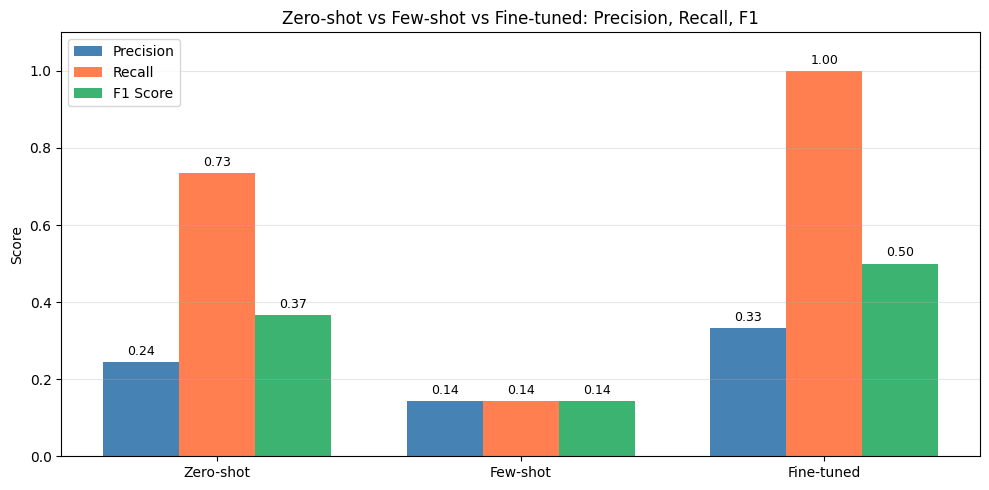

Comparison chart saved to Drive.


In [ ]:
# plotting a grouped bar chart comparing all three methods across all three metrics
# grouped bars make it easy to see at a glance which method wins on each metric

methods        = ['Zero-shot', 'Few-shot', 'Fine-tuned']
precision_vals = [zs_metrics['precision'], fs_metrics['precision'], ft_metrics['precision']]
recall_vals    = [zs_metrics['recall'],    fs_metrics['recall'],    ft_metrics['recall']]
f1_vals        = [zs_metrics['f1'],        fs_metrics['f1'],        ft_metrics['f1']]

x     = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

# drawing three bar groups, each offset by width so they sit side by side
bars1 = ax.bar(x - width, precision_vals, width, label='Precision', color='steelblue')
bars2 = ax.bar(x,          recall_vals,    width, label='Recall',    color='coral')
bars3 = ax.bar(x + width,  f1_vals,        width, label='F1 Score',  color='mediumseagreen')

# adding value labels on top of each bar so the chart is fully self-contained
for bar in [*bars1, *bars2, *bars3]:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title('Zero-shot vs Few-shot vs Fine-tuned: Precision, Recall, F1')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/comparison_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Comparison chart saved to Drive.')

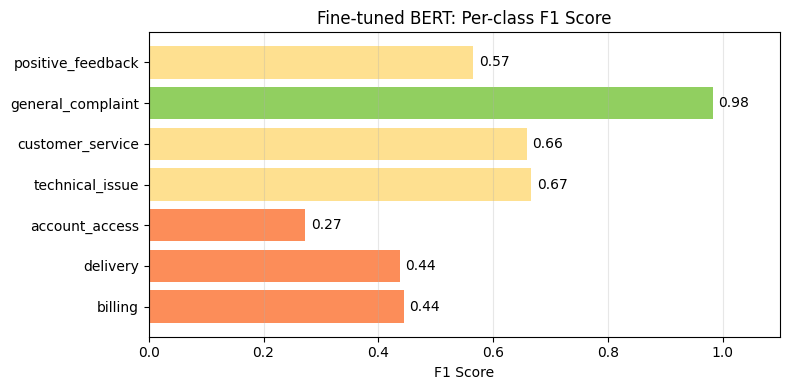

Per-class F1 chart saved to Drive.


In [ ]:
# computing per-class F1 for the fine-tuned model
# this shows which categories the model handles well and which it struggles with
# a class with low F1 usually means it is underrepresented in the training data

y_true_ft = mlb.transform(df_eval['true_tags'])
cleaned_ft = [
    [t for t in tags if t in ALL_CLASSES] or ['general_complaint']
    for tags in df_eval['finetuned_top3']
]
y_pred_ft = mlb.transform(cleaned_ft)

# average=None returns one F1 score per class instead of a single averaged score
per_class_f1 = f1_score(y_true_ft, y_pred_ft, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(8, 4))
# coloring bars from red (low F1) to green (high F1) for quick visual reading
colors = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']
bars = ax.barh(ALL_CLASSES, per_class_f1, color=[
    colors[min(int(f * 4), 4)] for f in per_class_f1
])

for bar, val in zip(bars, per_class_f1):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)

ax.set_xlim(0, 1.1)
ax.set_xlabel('F1 Score')
ax.set_title('Fine-tuned BERT: Per-class F1 Score')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()
print('Per-class F1 chart saved to Drive.')

In [ ]:
# printing 10 sample tickets side by side with all three model predictions
# this is the most intuitive way to understand what each model is actually doing

print('=' * 90)
print('Sample predictions from all three methods')
print('=' * 90)

for i in range(10):
    row  = df_eval.iloc[i]
    text = row['instruction']
    print(f'\nTicket #{i+1}:')
    print(f'  Text       : {text[:100]}...' if len(text) > 100 else f'  Text       : {text}')
    print(f'  True tags  : {row["true_tags"]}')
    print(f'  Zero-shot  : {row["zero_shot_top3"]}')
    print(f'  Few-shot   : {row["few_shot_top3"]}')
    print(f'  Fine-tuned : {row["finetuned_top3"]}')
    print('-' * 90)

Sample predictions from all three methods

Ticket #1:
  Text       : where to notify of problems with sign-up?
  True tags  : ['account_access']
  Zero-shot  : ['customer_service', 'technical_issue', 'account_access']
  Few-shot   : ['billing']
  Fine-tuned : ['account_access', 'customer_service', 'billing']
------------------------------------------------------------------------------------------

Ticket #2:
  Text       : wanna  use the {{Account Type}} profile help me
  True tags  : ['account_access']
  Zero-shot  : ['account_access', 'customer_service', 'technical_issue']
  Few-shot   : ['billing']
  Fine-tuned : ['account_access', 'customer_service', 'billing']
------------------------------------------------------------------------------------------

Ticket #3:
  Text       : I cannot retrieve the bloody PIN code of my profile
  True tags  : ['account_access']
  Zero-shot  : ['technical_issue', 'account_access', 'customer_service']
  Few-shot   : ['billing']
  Fine-tuned : ['acco

---
## Summary

You have now built a complete LLM-based support ticket tagger from scratch. Here is what each phase taught you:

| Phase | What you learned |
|-------|------------------|
| Data exploration | How to load HF datasets, map intents to tags, visualize distributions |
| Zero-shot | How NLI-based models classify without examples using `pipeline()` |
| Few-shot | How to engineer prompts with worked examples to guide model output |
| Fine-tuning | How BERT updates its weights on your data, tokenization, custom Trainer |
| Evaluation | How to compute F1/precision/recall for multi-label outputs and read results |

**All outputs saved to Google Drive:**
- `cleaned_tickets.csv` — preprocessed dataset with intent-to-tag mappings
- `zero_shot_results.csv` — Phase 2 predictions
- `few_shot_results.csv` — Phase 3 predictions
- `all_results.csv` — combined results used for evaluation
- `bert_finetuned/` — fine-tuned model and tokenizer (reload-ready, never retrain)
- `comparison_chart.png` — grouped bar chart of all three methods
- `per_class_f1.png` — per-category F1 for the fine-tuned model
- `data_exploration.png` — Phase 1 distribution charts

In [38]:
import json, re

notebook_path = "/content/drive/MyDrive/Colab Notebooks/auto_tagging_support_tickets (2).ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

widgets_meta = nb.get("metadata", {}).get("widgets", {})

for key, val in widgets_meta.items():
    if isinstance(val, dict):
        # Separate UUID widget keys from metadata keys (version_major, version_minor, state)
        uuid_pattern = re.compile(r'^[0-9a-f]{32}$')

        state_items = {}
        meta_items = {}

        for k, v in val.items():
            if uuid_pattern.match(k):
                state_items[k] = v   # these are the widget states
            else:
                meta_items[k] = v   # version_major, version_minor, etc.

        print(f"Found {len(state_items)} widget states to move into 'state' key")

        # Rebuild the correct structure
        val.clear()
        val["state"] = state_items      # wrap all UUIDs inside "state"
        val["version_major"] = meta_items.get("version_major", 2)
        val["version_minor"] = meta_items.get("version_minor", 0)

# Save the fixed notebook
with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

# ── Verify ────────────────────────────────────────────────────────────
with open(notebook_path, "r", encoding="utf-8") as f:
    nb2 = json.load(f)

for key, val in nb2.get("metadata", {}).get("widgets", {}).items():
    has_state = "state" in val
    state_count = len(val.get("state", {}))
    print(f"✅ 'state' key exists: {has_state}, with {state_count} widget states")


Found 297 widget states to move into 'state' key
✅ 'state' key exists: True, with 297 widget states
